In [1]:
# Importando as bibliotecas necessárias.
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [2]:
# Reset o gerador de sequências PN.
seed = 4
np.random.seed(seed)

### Gerando o conjunto de dados.

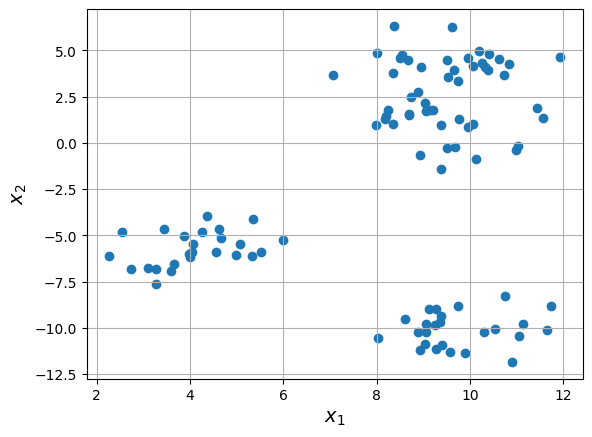

In [3]:
# Define número de exemplos.
N = 100

X, y = make_blobs(n_samples=N, centers=4, random_state=seed)

plt.scatter(X[:,0], X[:,1])
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.grid()
plt.show()

### Quantos *clusters* são necessários?

Vamos calcular a inércia para k variando de 1 a 10.

In [4]:
inercia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

### Plotar a curva de inércia e a reta entre extremos

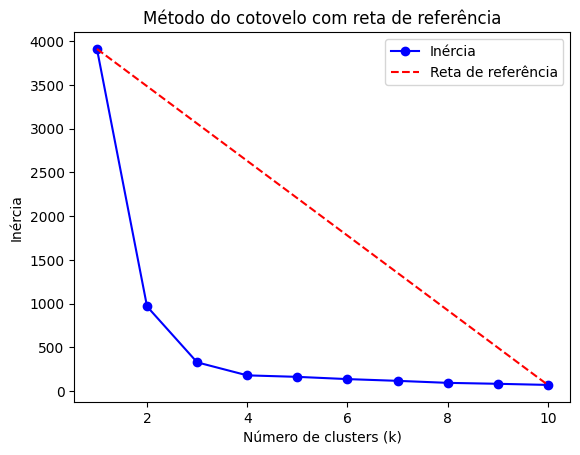

In [5]:
k_values = range(1, 11)
plt.plot(k_values, inercia, 'bo-', label='Inércia')

# Definir extremos (primeiro e último pontos)
primeiro_ponto = (1, inercia[0])
ultimo_ponto = (10, inercia[-1])

# Equação da reta entre os extremos (y = a*x + b)
x = np.array([1, 10])
y = np.array([inercia[0], inercia[-1]])
a, b = np.polyfit(x, y, 1)

# Plotar a reta
plt.plot(x, a*x + b, 'r--', label='Reta de referência')

plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do cotovelo com reta de referência')
plt.legend()
plt.show()

###  Identificar o ponto mais distante da reta

In [6]:
# Calcular distâncias dos pontos à reta
distancias = []
for k in range(1, 11):
    y_reta = a * k + b
    distancia = abs(inercia[k-1] - y_reta)
    distancias.append(distancia)

# Encontrar o k com maior distância
k_otimo = np.argmax(distancias) + 1  # +1 pois o índice começa em 0
print(f"Número ideal de clusters: k = {k_otimo}")

Número ideal de clusters: k = 3


### Identificando os clusters.

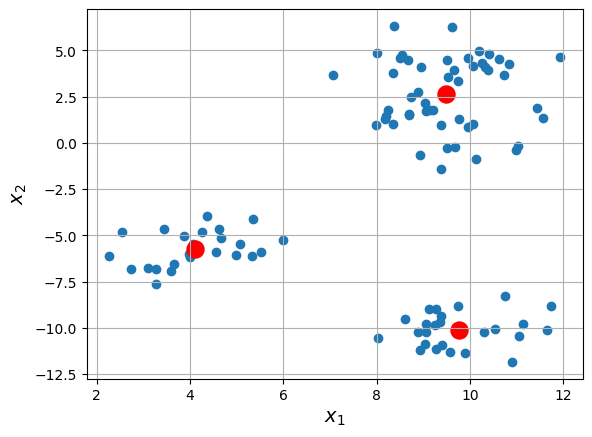

In [7]:
# Define número de clusters.
k = k_otimo

# Instancia objeto da classe KMeans.
kmeans = KMeans(n_clusters=k, random_state=seed)

# Treina objeto da classe KMeans.
kmeans.fit(X)

plt.scatter(X[:,0], X[:,1])
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=150, c='red')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.grid()
plt.show()